In [3]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Sample dataset
dataset = [
    ['milk', 'bread', 'eggs'],
    ['milk', 'bread'],
    ['milk', 'eggs'],
    ['bread', 'butter'],
    ['bread', 'eggs'],
    ['milk', 'bread', 'butter', 'eggs']
]

# Convert transactions into one-hot encoded DataFrame
te = TransactionEncoder()
data = te.fit(dataset).transform(dataset)
df = pd.DataFrame(data, columns=te.columns_)

# Generate frequent itemsets
frequent_items = apriori(df, min_support=0.3, use_colnames=True)
print("Frequent Itemsets:")
print(frequent_items)

# Generate association rules
rules = association_rules(frequent_items, metric="lift", min_threshold=1)
print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Frequent Itemsets:
    support             itemsets
0  0.833333              (bread)
1  0.333333             (butter)
2  0.666667               (eggs)
3  0.666667               (milk)
4  0.333333      (butter, bread)
5  0.500000        (bread, eggs)
6  0.500000        (milk, bread)
7  0.500000         (milk, eggs)
8  0.333333  (milk, bread, eggs)

Association Rules:
     antecedents    consequents   support  confidence   lift
0       (butter)        (bread)  0.333333    1.000000  1.200
1        (bread)       (butter)  0.333333    0.400000  1.200
2         (milk)         (eggs)  0.500000    0.750000  1.125
3         (eggs)         (milk)  0.500000    0.750000  1.125
4  (milk, bread)         (eggs)  0.333333    0.666667  1.000
5  (bread, eggs)         (milk)  0.333333    0.666667  1.000
6         (milk)  (bread, eggs)  0.333333    0.500000  1.000
7         (eggs)  (milk, bread)  0.333333    0.500000  1.000


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


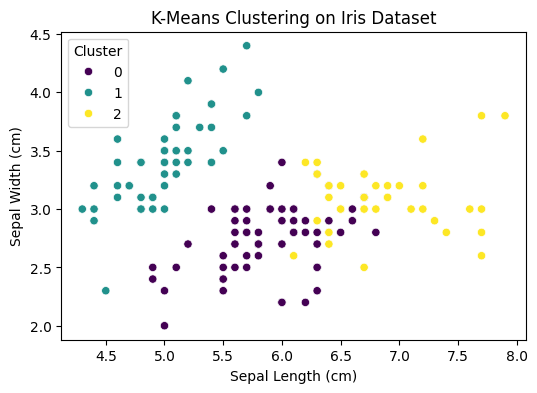

In [6]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset from CSV file
data = pd.read_csv("C:\\Users\\shubh\\Downloads\\Iris.csv")

# Check first few rows
print(data.head())

# Drop non-numeric columns (like Id, Species)
X = data.drop(['Id', 'Species'], axis=1)

# Apply K-Means clustering (3 clusters for 3 species)
kmeans = KMeans(n_clusters=3, random_state=0)
X['Cluster'] = kmeans.fit_predict(X)

# Visualize clusters (SepalLengthCm vs SepalWidthCm)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], hue=X['Cluster'], palette='viridis')
plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()
